<a href="https://colab.research.google.com/github/Fav0urcodes/guitar-learning-web-app/blob/main/Data_cleaning_Newyork_city_bikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load the uploaded file
df = pd.read_excel('/content/sample_data/newyork citybikes unclean.xlsx')

# Show the first 5 rows to ensure it loaded correctly
df.head()

,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
2,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
3,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday
4,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday


In [4]:
# 1. Remove exact duplicates
df.drop_duplicates(inplace=True)

# 2. Remove rows with empty cells (blanks)
df.dropna(inplace=True)

# 3. Fix the Age Range to get a single number
df['Age_Start'] = df['Birth Year'].astype(int) # Corrected column name

# 4. Create the Age Group
df['Age Group'] = (df['Age_Start'] // 10 * 10).astype(str) + 's'

# 5. Convert 'starttime' to a real date to get the Day of Week
df['Start Time'] = pd.to_datetime(df['Start Time']) # Corrected column name
df['Day of Week'] = df['Start Time'].dt.day_name()

print("Cleanup complete! New columns 'Age Group' and 'Day of Week' are ready.")

Cleanup complete! New columns 'Age Group' and 'Day of Week' are ready.


In [5]:
# Q1: Most popular pick-up locations
print("--- Top 5 Pick-up Locations ---")
print(df['Start Station Name'].value_counts().head(5))

# Q2 & Q5: Average trip duration by Age Group
print("\n--- Avg Trip Duration by Age Group ---")
# Trip Duration is the column name for seconds
avg_duration = df.groupby('Age Group')['Trip Duration'].mean()
print(avg_duration)

# Q3: Which age group rents the most?
print("\n--- Total Rentals by Age Group ---")
print(df['Age Group'].value_counts())

--- Top 5 Pick-up Locations ---
Start Station Name
Grove St PATH     2115
Exchange Place    1225
Sip Ave           1084
Hamilton Park     1069
Morris Canal       710
Name: count, dtype: int64

--- Avg Trip Duration by Age Group ---
Age Group
1930s     277.081081
1940s    2790.766667
1950s     535.009524
1960s     517.171155
1970s     470.604435
1980s     610.363207
1990s     638.293722
Name: Trip Duration, dtype: float64

--- Total Rentals by Age Group ---
Age Group
1980s    8469
1970s    3878
1990s    1784
1960s    1671
1950s     945
1940s      60
1930s      37
Name: count, dtype: int64


In [6]:
# Q4: How rentals vary by User Type and Day
# create a table with Days as rows and User Types as columns
pivot_table = df.groupby(['Day of Week', 'User Type']).size().unstack()

#Sort days in order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days_order)

print("\n--- Rentals by Day and User Type ---")
print(pivot_table)


--- Rentals by Day and User Type ---
User Type    One-time user  Subscriber
Day of Week                           
Monday                  52        2474
Tuesday                 24        2436
Wednesday               39        3262
Thursday                19        2934
Friday                  27        2422
Saturday                93        1497
Sunday                  64        1501


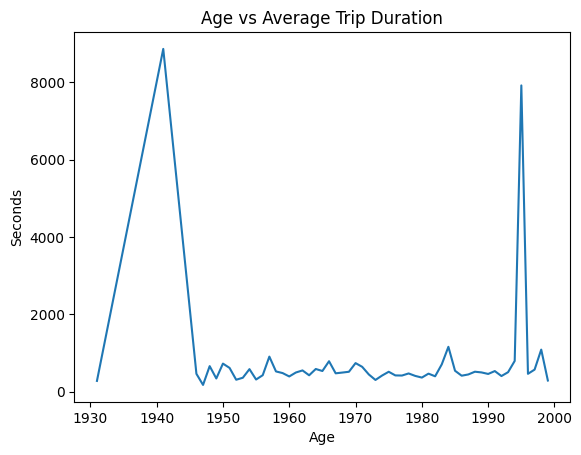

The correlation between Age and Trip Duration is: 0.0036


In [7]:
# Q5: Does user age impact the average bike trip duration?
import matplotlib.pyplot as plt

# 1. Calculate the average duration for EVERY age
age_impact = df.groupby('Age_Start')['Trip Duration'].mean()

# 2. Visualize it
age_impact.plot(kind='line', title='Age vs Average Trip Duration', ylabel='Seconds', xlabel='Age')
plt.show()

# 3. Check the correlation number
correlation = df['Age_Start'].corr(df['Trip Duration'])
print(f"The correlation between Age and Trip Duration is: {correlation:.4f}")